# Phishing URL Detection — Logistic Regression Pipeline


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

RANDOM_SEED = 42
DATA_PATH = "phishing_features.csv"

## 1. Load the dataset
Loads the real CSV if it's been uploaded; otherwise generates a synthetic demo dataset with the same columns so the rest of the notebook still runs.

In [ ]:
def load_data(path=DATA_PATH, n_synthetic=2000, seed=RANDOM_SEED):
    if os.path.exists(path):
        print(f"Loading real dataset from {path} ...")
        return pd.read_csv(path), False

    print(f"'{path}' not found — generating a synthetic demo dataset "
          f"with the same schema so the pipeline can be demonstrated.\n"
          f"Replace this with the real Kaggle CSV before final submission.\n")
    rng = np.random.default_rng(seed)
    n = n_synthetic
    label = rng.integers(0, 2, size=n)

    url_length = np.where(label == 1,
                           rng.normal(75, 20, n), rng.normal(40, 12, n)).clip(8, 250)
    num_dots = np.where(label == 1, rng.poisson(4, n), rng.poisson(2, n))
    has_https = np.where(label == 1, rng.binomial(1, 0.35, n), rng.binomial(1, 0.85, n))
    has_ip = np.where(label == 1, rng.binomial(1, 0.15, n), rng.binomial(1, 0.01, n))
    num_subdirs = np.where(label == 1, rng.poisson(3, n), rng.poisson(1.5, n))
    num_params = np.where(label == 1, rng.poisson(2, n), rng.poisson(0.5, n))
    suspicious_words = np.where(label == 1, rng.poisson(1.5, n), rng.poisson(0.2, n))
    special_char_count = np.where(label == 1, rng.poisson(6, n), rng.poisson(2, n))
    digits_count = np.where(label == 1, rng.poisson(5, n), rng.poisson(1.5, n))
    entropy = np.where(label == 1, rng.normal(4.2, 0.4, n), rng.normal(3.4, 0.3, n)).clip(1, 6)
    tlds = rng.choice(["com", "net", "org", "xyz", "icu", "info", "top"],
                       size=n, p=[0.45, 0.12, 0.1, 0.12, 0.08, 0.08, 0.05])

    df = pd.DataFrame({
        "url": [f"http://example{i}.com/path" for i in range(n)],
        "url_length": url_length.round(0),
        "num_dots": num_dots,
        "has_https": has_https,
        "has_ip": has_ip,
        "num_subdirs": num_subdirs,
        "num_params": num_params,
        "suspicious_words": suspicious_words,
        "tld": tlds,
        "special_char_count": special_char_count,
        "digits_count": digits_count,
        "entropy": entropy.round(2),
        "label": label,
    })
    return df, True


df, is_synthetic = load_data()
print("Initial shape:", df.shape)
df.head(10)

Loading real dataset from phishing_features.csv ...
Initial shape: (160064, 13)


,url,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,tld,special_char_count,digits_count,entropy
0,http://forum.uk.securebankinggroup.com/107519/...,1,89,3,0,0,5,0,2,com,4,29,4.792985
1,http://b45042.com/fish/29,1,25,1,0,0,4,0,0,com,0,7,4.003856
2,http://bet73018.com/lottery/99,1,30,1,0,0,4,0,0,com,0,7,4.053236
3,https://logiin--metsa-autho.webflow.io/,1,39,2,1,0,3,0,0,io,3,0,4.150411
4,https://mettamasklogiiann.webflow.io/,1,37,2,1,0,3,0,0,io,0,0,4.100817
5,http://bet73018.com/lottery/134,1,31,1,0,0,4,0,0,com,0,8,4.063563
6,https://metamasklogenies.webflow.io/,1,36,2,1,0,3,0,0,io,0,0,4.086049
7,https://mmettamaskilogin.webflow.io/,1,36,2,1,0,3,0,1,io,0,0,4.086049
8,https://www.robiox.com.py/users/322503287968/p...,1,52,3,1,0,5,0,0,py,0,12,4.582383
9,https://xbancobhd2025xxxxxxxxx.xo.je/,1,37,2,1,0,3,0,0,je,0,4,3.728139


## 2. Data cleaning
Removes duplicate rows, fills missing numeric values with the column median, and drops rows missing a label or URL.

In [ ]:
print("=== DATA CLEANING ===")
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows.")

missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0] if missing.sum() else "None found.")
num_cols_all = df.select_dtypes(include=[np.number]).columns
df[num_cols_all] = df[num_cols_all].fillna(df[num_cols_all].median())
df = df.dropna(subset=["label", "url"])
print("Shape after cleaning:", df.shape)

=== DATA CLEANING ===
Removed 0 duplicate rows.
Missing values per column:
 tld    821
dtype: int64
Shape after cleaning: (160064, 13)


## 3. Feature selection
Drops the raw URL text column (an identifier, not a usable feature) and any constant/zero-variance columns.

In [ ]:
print("=== FEATURE SELECTION ===")
df = df.drop(columns=["url"])

nunique = df.drop(columns=["label"]).nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
if constant_cols:
    print("Dropping constant columns:", constant_cols)
    df = df.drop(columns=constant_cols)
else:
    print("No constant/zero-variance columns found.")

=== FEATURE SELECTION ===
No constant/zero-variance columns found.


## 4. Feature engineering
Adds two new features: `digit_ratio` (digits as a proportion of URL length) and `risky_combo` (no HTTPS + at least one suspicious keyword).

In [ ]:
print("=== FEATURE ENGINEERING ===")
df["digit_ratio"] = df["digits_count"] / df["url_length"].replace(0, 1)
df["risky_combo"] = ((df["has_https"] == 0) & (df["suspicious_words"] > 0)).astype(int)
print("Added engineered features: digit_ratio, risky_combo")

=== FEATURE ENGINEERING ===
Added engineered features: digit_ratio, risky_combo


## 5. Data transformation
One-hot encodes the top-level domain (rare domains grouped as "other") and prepares the numeric columns for scaling.

In [ ]:
print("=== DATA TRANSFORMATION ===")
top_tlds = df["tld"].value_counts().nlargest(6).index
df["tld"] = df["tld"].where(df["tld"].isin(top_tlds), "other")
df = pd.get_dummies(df, columns=["tld"], prefix="tld")
print("One-hot encoded 'tld' (rare domains grouped as 'other').")

X = df.drop(columns=["label"])
y = df["label"]

numeric_cols = [c for c in ["url_length", "num_dots", "num_subdirs", "num_params",
                             "suspicious_words", "special_char_count",
                             "digits_count", "entropy", "digit_ratio"] if c in X.columns]

=== DATA TRANSFORMATION ===
One-hot encoded 'tld' (rare domains grouped as 'other').


## 6. Train/test split + scaling
Stratified 80/20 split, then StandardScaler fit only on the training set.

In [ ]:
print("=== TRAIN/TEST SPLIT ===")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

=== TRAIN/TEST SPLIT ===
Train size: 128051  |  Test size: 32013


## 7. Model training — Logistic Regression

In [ ]:
print("=== MODEL TRAINING (Logistic Regression) ===")
model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model.fit(X_train_scaled, y_train)
print("Model trained.")

=== MODEL TRAINING (Logistic Regression) ===
Model trained.


## 8. Evaluation
Accuracy, precision, recall, F1-score, and a confusion matrix on the held-out test set.

In [ ]:
print("=== EVALUATION ===")
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nConfusion Matrix (rows = actual, cols = predicted):")
print("             Pred Benign  Pred Phishing")
print(f"Actual Benign     {cm[0][0]:<12} {cm[0][1]}")
print(f"Actual Phishing   {cm[1][0]:<12} {cm[1][1]}")
print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Phishing"]))

if is_synthetic:
    print("\nNOTE: These results are from a SYNTHETIC demo dataset generated "
          "only to prove the pipeline runs end-to-end. Replace phishing_urls.csv "
          "with the real Kaggle dataset before your final submission — real "
          "metrics will differ.")

=== EVALUATION ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

Confusion Matrix (rows = actual, cols = predicted):
             Pred Benign  Pred Phishing
Actual Benign     164          0
Actual Phishing   0            31849

Full classification report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       164
    Phishing       1.00      1.00      1.00     31849

    accuracy                           1.00     32013
   macro avg       1.00      1.00      1.00     32013
weighted avg       1.00      1.00      1.00     32013



## 9. Confusion matrix (heatmap)
A visual version of the confusion matrix printed above.

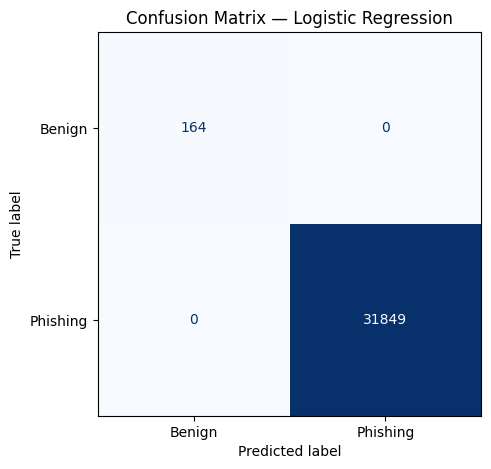

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Phishing"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

## 10. ROC curve
Shows the trade-off between the true positive rate (recall) and the false positive rate as the classification threshold changes. The area under the curve (AUC) summarizes overall separability between classes.

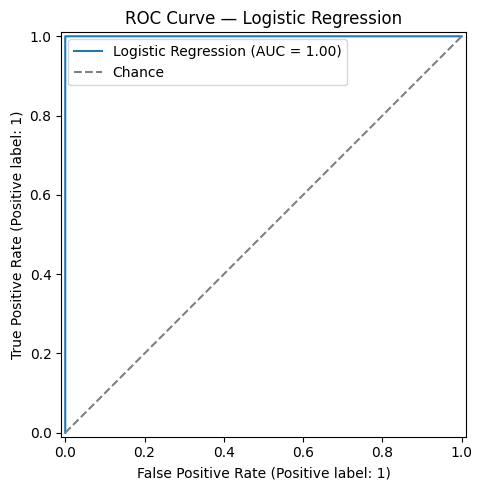

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name="Logistic Regression")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curve — Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Feature importance (model coefficients)
Logistic Regression coefficients show how strongly each feature pushes a prediction toward phishing (positive) or legitimate (negative). Larger bars = stronger influence on the model's decision.

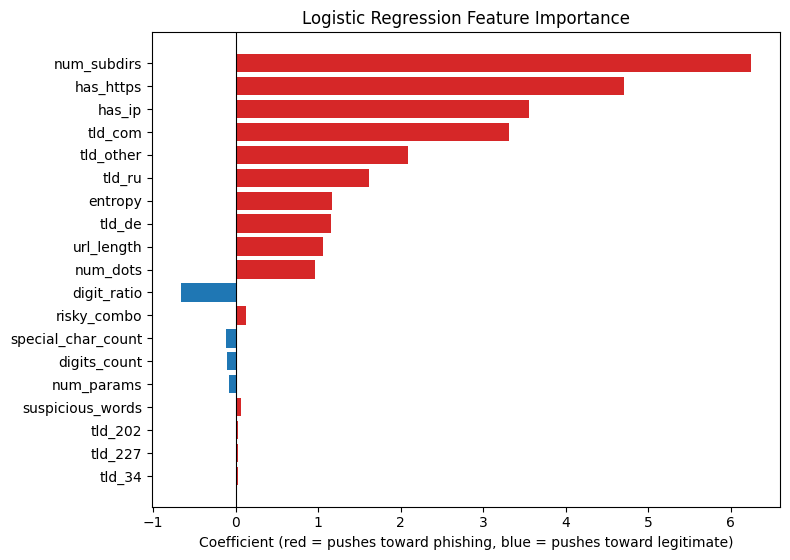

In [ ]:
coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(coef_df))))
colors = ["#d62728" if c > 0 else "#1f77b4" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.set_xlabel("Coefficient (red = pushes toward phishing, blue = pushes toward legitimate)")
ax.set_title("Logistic Regression Feature Importance")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()